/tmp/ipykernel_486869/2292154661.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  trades = pd.read_csv(


,Equity,DrawdownPct,DrawdownDuration
datetime,,,
2020-01-01 00:00:00,100000.0,0.0,NaN
2020-01-01 04:00:00,100000.0,0.0,NaN
2020-01-01 08:00:00,100000.0,0.0,NaN
2020-01-01 12:00:00,100000.0,0.0,NaN
2020-01-01 16:00:00,100000.0,0.0,NaN


,Size,EntryBar,ExitBar,EntryPrice,ExitPrice,PnL,ReturnPct,EntryTime,ExitTime,Duration
0,-11,135,156,8406.13404,8675.6900,-2965.11556,-0.032067,2020-01-23 12:00:00,2020-01-27 00:00:00,3 days 12:00:00
1,-10,207,213,9164.44438,9458.2943,-2938.49920,-0.032064,2020-02-04 12:00:00,2020-02-05 12:00:00,1 days 00:00:00
2,-9,274,285,9963.27352,9484.0210,4313.27268,0.048102,2020-02-15 16:00:00,2020-02-17 12:00:00,1 days 20:00:00
3,-10,333,339,9376.39962,8927.5965,4488.03120,0.047865,2020-02-25 16:00:00,2020-02-26 16:00:00,1 days 00:00:00
4,-11,340,385,8813.47772,9096.0742,-3108.56128,-0.032064,2020-02-26 20:00:00,2020-03-05 08:00:00,7 days 12:00:00


Win rate: 39.77%
Average Trade PnL: -5778.79%
Max Drawdown: -39.64%


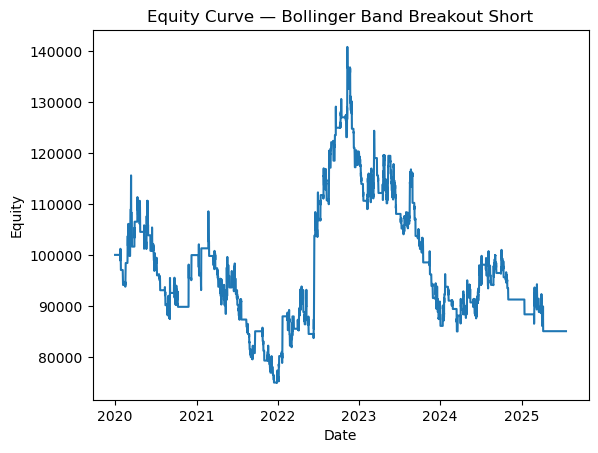

In [ ]:
# ---
# jupyter:
#   kernelspec:
#     display_name: "Algo Bot (pandas_python)"
#     language: python
#     name: algo_bot_env
# ---
# Analysis of Bollinger Band Backtest Results
import pandas as pd
import matplotlib.pyplot as plt

# Load equity curve
eq = pd.read_csv(
    '../results/BTC_USDT_bollinger_band_breakout_short_20250720_231559_equity.csv',
    index_col=0,
    parse_dates=True
)
trades = pd.read_csv(
    '../results/BTC_USDT_bollinger_band_breakout_short_20250720_231559_trades.csv',
    index_col=0,
    parse_dates=True
)

# Display DataFrames
display(eq.head())
display(trades.head())

# Compute summary metrics
win_rate = (trades['PnL'] > 0).mean()
avg_trade = trades['PnL'].mean()
max_drawdown = (eq['Equity'] / eq['Equity'].cummax() - 1).min()

# Print metrics
print(f"Win rate: {win_rate:.2%}")
print(f"Average Trade PnL: {avg_trade:.2%}")
print(f"Max Drawdown: {max_drawdown:.2%}")

# Plot equity curve
plt.figure()
plt.plot(eq.index, eq['Equity'])
plt.title('Equity Curve — Bollinger Band Breakout Short')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.show()

dd = eq['Equity'] / eq['Equity'].cummax() - 1
plt.figure(figsize=(10,4))
plt.fill_between(dd.index, dd, 0, color='red')
plt.title('Drawdown Curve')
plt.ylabel('Drawdown')
plt.show()
